# Assignment 1: Epidemiological Models
# Group 5

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

## 2. Part 1: Parameter Analysis Function

In this section we investigated how different recovery rates(betas) affect the dynamics of the SIRD model. 
The transmission rate, mortality rate, total population, initial number of infected individuals, 
and simulation duration are kept constant, while the recovery rate γ is varied from 0.05 to 0.25.

For each recovery rate, the model calculates the basic reproduction number, peak number of infectious individuals,
the day of the infection peak, and the total number of deaths at the end of the simulation.

In [2]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters
    ----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns
    -------
    pandas.DataFrame
        Results summary for each recovery rate
    """

    # Recovery rates required in the assignment
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]

    # List where summary results will be stored
    results = []

    # Initial conditions
    S0 = N - I0
    R0_initial = 0
    D0 = 0
    y0 = [S0, I0, R0_initial, D0]

    # Time points
    t = np.linspace(0, simulation_days - 1, simulation_days)

    # Create figure for infectious epidemic curves
    plt.figure(figsize=(10, 6))

    # Run the SIRD model for each recovery rate
    for gamma in gamma_values:

        sol = odeint(
            sird_model,
            y0,
            t,
            args=(beta, gamma, mu)
        )

        S, I, R, D = sol.T

        # Calculate required epidemic measures
        R0 = beta / gamma
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        total_deaths = D[-1]

        # Save results
        results.append([
            gamma,
            R0,
            peak_infected,
            peak_day,
            total_deaths
        ])

        # Plot infectious curve for this recovery rate
        plt.plot(
            t,
            I,
            linewidth=2,
            label=f'γ = {gamma:.2f}, R₀ = {R0:.1f}'
        )

    # Format epidemic plot
    plt.xlabel('Time (days)')
    plt.ylabel('Number of Infectious Individuals')
    plt.title('Effect of Recovery Rate on SIRD Epidemic Dynamics')
    plt.legend(title='Recovery rate')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Create results DataFrame
    results_df = pd.DataFrame(
        results,
        columns=[
            'gamma',
            'R0',
            'peak_infected',
            'peak_day',
            'total_deaths'
        ]
    )

    return results_df

## The SIRD model from computer assignment

In [3]:
# 🟡 adapt the differential equations for the extended model
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - ((gamma + mu) * I)
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


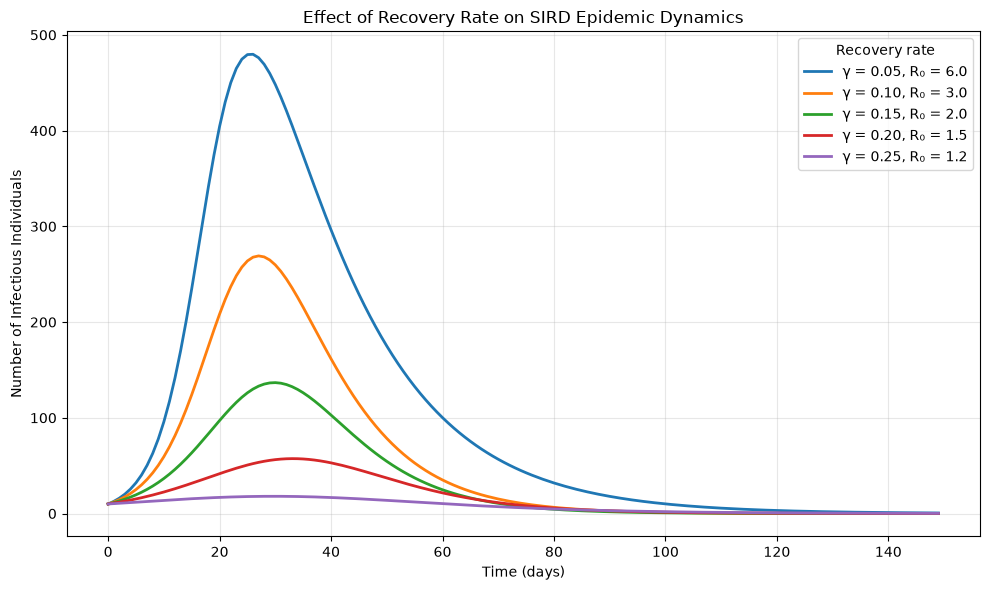

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,479.737984,26,165.413925
1,0.10,3.0,269.138176,27,83.572705
2,0.15,2.0,136.756407,30,47.712503
3,0.20,1.5,57.359889,33,26.019199
4,0.25,1.2,18.021355,30,11.436114


In [4]:
results_df = analyze_recovery_rates(
    beta=0.3,
    mu=0.01,
    N=1000,
    I0=10,
    simulation_days=150
)

results_df

## 3. Part 2: Scenario comparison

A-High Transmission Scenario: beta = 0.40, mu = 0.02, N = 1000, I0 = 5
B-Low Transmission Scenario: beta = 0.20, mu = 0.005, N = 1000, I0 = 5

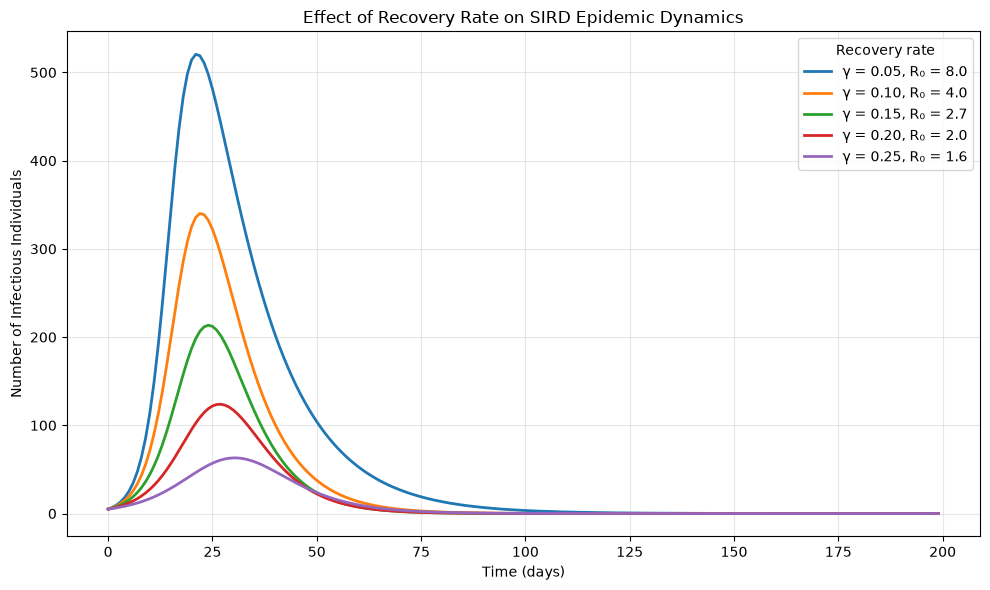

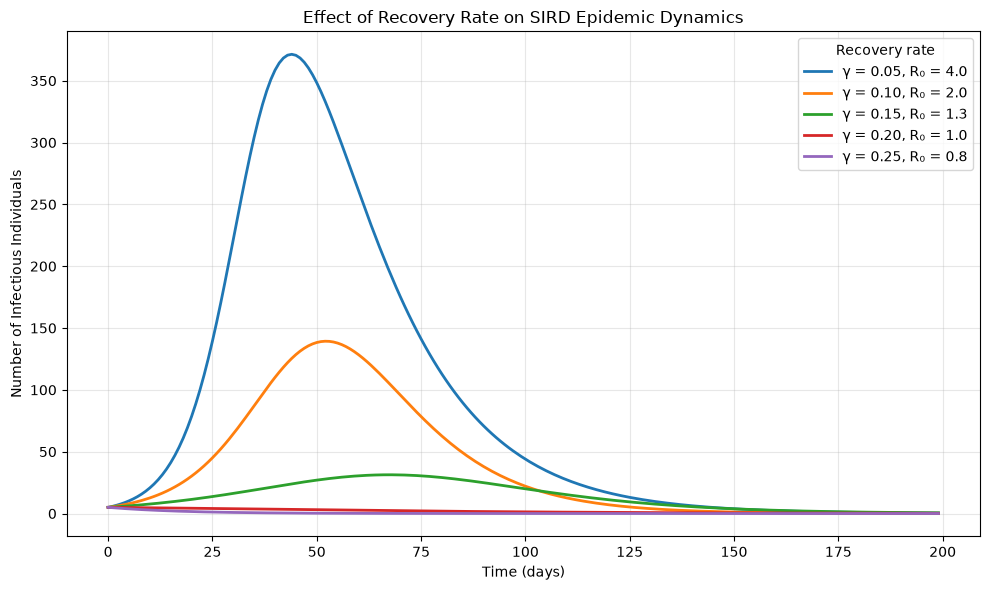

In [5]:
# Run the required recovery-rate analysis for both scenarios.
scenario_a_results = analyze_recovery_rates(
    beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
)
scenario_b_results = analyze_recovery_rates(
    beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200
)

# Round continuous-model outputs to two decimal places for readable tables.
scenario_a_results = scenario_a_results.round(2)
scenario_b_results = scenario_b_results.round(2)

### 3.1 Results

The tables below report the R0(Basic Reproduction Number), peak number of infectious people, peak day, and total deaths for each recovery rate.

In [6]:
print('Scenario A - High Transmission')
display(scenario_a_results)

print('Scenario B - Low Transmission')
display(scenario_b_results)

Scenario A - High Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.58,21,284.76
1,0.10,4.00,340.14,22,159.89
2,0.15,2.67,213.47,24,102.61
3,0.20,2.00,123.89,27,67.42
4,0.25,1.60,63.05,30,42.69


Scenario B - Low Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.36,44,88.22
1,0.10,2.00,139.33,52,36.70
2,0.15,1.33,31.34,67,13.64
3,0.20,1.00,5.00,0,1.83
4,0.25,0.80,5.00,0,0.43


### 3.2 Comparative visualization

The plots compare infectious-population curves at the same recovery rates. Keeping the gamma colors consistent makes it easier to compare the severity and timing of each outbreak.

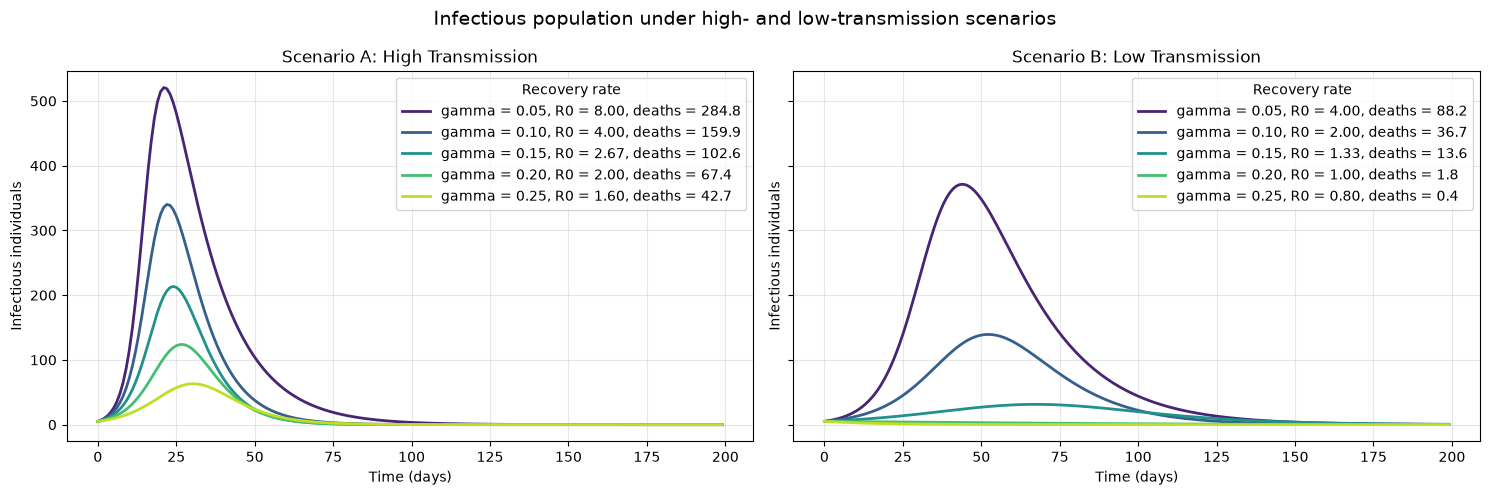

In [7]:
gamma_values = [0.05, 0.10, 0.15, 0.20, 0.25]

t = np.linspace(0, 199, 200)
scenarios = {
    'Scenario A: High Transmission': (0.4, 0.02),
    'Scenario B: Low Transmission': (0.2, 0.005)
}
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gamma_values)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (scenario_name, (beta, mu)) in zip(axes, scenarios.items()):
    for gamma, color in zip(gamma_values, colors):
        # Solve the SIRD equations with the scenario-specific beta and mu.
        solution = odeint(sird_model, [995, 5, 0, 0], t, args=(beta, gamma, mu))
        R0 = beta / gamma
        total_deaths = solution[-1, 3]
        label = f'gamma = {gamma:.2f}, R0 = {R0:.2f}, deaths = {total_deaths:.1f}'
        ax.plot(t, solution[:, 1], color=color, linewidth=2, label=label)
    ax.set_title(scenario_name)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infectious individuals')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Recovery rate')

fig.suptitle('Infectious population under high- and low-transmission scenarios', fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Public-health interpretation

Scenario A (high transmission) is worse for public health  It has both a higher transmission rate (beta = 0.4) and mortality rate (mu = 0.02), causing faster, larger outbreaks and more deaths across every recovery rate. As an example at gamma=0.05  Scenario A peaks at 520.58 infections on day 21 and causes 284.76 deaths. Scenario B peaks later, at 371.36 infections on day 44, and causes 88.22 deaths.

At gamma=0.25  Scenario A still has R0 = 1.6, a peak of 63.05 infections, and 42.69 deaths, meaning the disease continues to spread. In Scenario B (low transmission), gamma= 0.25 gives R0 = 0.8, so transmission declines instead of creating a major outbreak; peak infections remain at the initial 5 people and total deaths are only 0.43.


Thus, we can say that the high transmission scenario would put more strain on healthcare services than a low transmission scenario (Scenario B) because the R0 remains above 1 at all tested recovery rates. B becomes controllable at around 0.20 recovery rate as R0 reaches 1 and at y=0.25 r0 drops to 0.83.

## 4. Part 3: Policy recommendations


### 4.1 Parameter impact analysis

Increasing the recovery rate reduces peak infections and total deaths because infected people leave the infectious compartment more quickly. 


In Scenario A, as γ increases from 0.05 to 0.25: R₀ drops from 8.00 to 1.60, peak from 520.58 to 63.05, and deaths from 284.76 to 42.69
In Scenario B, as γ increases: R₀ drops from 4.00 to 0.80, peak from 371.36 to 5.00, and deaths from 88.22 to 0.43
At γ = 0.20, Scenario B has R₀ = 1.00 (epidemic threshold), so infections barely grow.

### 4.2 Intervention analysis

Take Scenario A at the baseline gamma = 0.10. A 50% increase in recovery rate gives:

$$y_{intervention} = 0.10 \times 1.50 = 0.15$$

From the Scenario A table, total deaths decrease from approximately 159.89 at gamma = 0.10 to 102.61 at gamma = 0.15. Thus:

$$\text{deaths prevented} = 159.89 - 102.61 = 57.28$$
$$\text{percentage reduction} = \frac{57.28}{159.89} \times 100 \approx 35.8\%$$

Under the model assumptions, an intervention that raises recovery by 50% would prevent about 57 deaths per 1,000 people in this high-transmission scenario.

### 4.3 Real-world application

Timely administration of antiviral drugs